In [18]:
from google.colab import drive
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# Save model to .h5 file
model.save('devnagari_fcn_model.h5')
print("Model saved successfully as devnagari_fcn_model.h5")

# Load model to verify
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully. Ready for use.")

Model saved successfully as devnagari_fcn_model.h5


Model loaded successfully. Ready for use.


In [20]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from PIL import Image

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [21]:
def load_images_from_folder(folder):
    images = []
    labels = []
    # Sort folders to ensure consistent mapping (digit_0=0, digit_1=1, etc.)
    class_names = sorted(os.listdir(folder))
    class_map = {name: i for i, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path): continue

        label = class_map[class_name]
        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                # Load image, convert to grayscale ("L"), resize to 28x28
                img = Image.open(img_path).convert("L")
                img = img.resize((28, 28))
                # Normalize to range [0, 1]
                img_array = np.array(img) / 255.0
                images.append(img_array)
                labels.append(label)
            except:
                continue

    return np.array(images), np.array(labels)

# Update these paths based on where your zip file extracted
train_dir = "/content/drive/MyDrive/AI & ML/week4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI & ML/week4/DevanagariHandwrittenDigitDataset/Test"

print("Loading Train and Test data...")
x_train, y_train_raw = load_images_from_folder(train_dir)
x_test, y_test_raw = load_images_from_folder(test_dir)

# One-hot encode labels (10 classes for digits 0-9)
y_train = to_categorical(y_train_raw, num_classes=10)
y_test = to_categorical(y_test_raw, num_classes=10)

print(f"Loaded {len(x_train)} training images.")
print(f"Loaded {len(x_test)} testing images.")

Loading Train and Test data...
Loaded 3631 training images.
Loaded 3000 testing images.


In [22]:
# ==========================================
# Task 2: Build the FCN Model
# ==========================================

model = models.Sequential([
    # Input layer and Flattening
    layers.Input(shape=(28, 28)),
    layers.Flatten(),

    # Hidden Layer 1: 64 neurons, Sigmoid
    layers.Dense(64, activation='sigmoid'),

    # Hidden Layer 2: 128 neurons, Sigmoid
    layers.Dense(128, activation='sigmoid'),

    # Hidden Layer 3: 256 neurons, Sigmoid
    layers.Dense(256, activation='sigmoid'),

    # Output Layer: 10 units, Softmax
    layers.Dense(10, activation='softmax')
])

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# ==========================================
# Task 3: Compile the Model
# ==========================================

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==========================================
# Task 4: Train the Model
# ==========================================

# Optional: Add Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_devnagari_model.keras', save_best_only=True)
]

history = model.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.9208 - loss: 0.2217 - val_accuracy: 0.4938 - val_loss: 4.0588
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9339 - loss: 0.1889 - val_accuracy: 0.4677 - val_loss: 4.4642
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9408 - loss: 0.1759 - val_accuracy: 0.4649 - val_loss: 4.6273
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9425 - loss: 0.1678 - val_accuracy: 0.4649 - val_loss: 4.7251


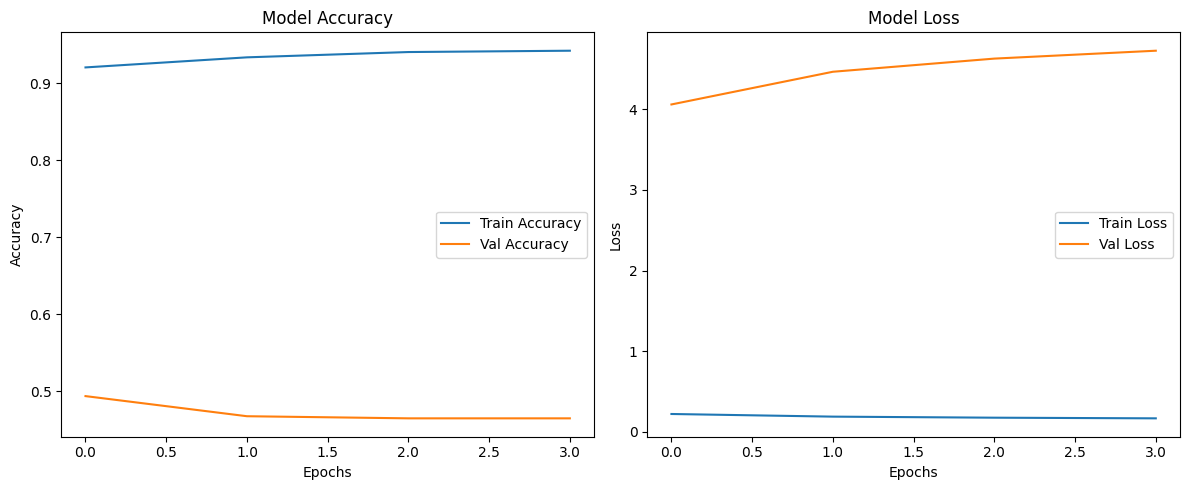

In [25]:

# ==========================================
# Visualization (Deliverable)
# ==========================================

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [26]:
# Task 5: Evaluate on Test Set
if len(x_test) > 0 and len(y_test) > 0:
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    print(f"Final Test Accuracy: {test_acc*100:.2f}%")

    # Task 7: Predictions
    sample_images = x_test[:5]
    predictions = model.predict(sample_images)
    predicted_digits = np.argmax(predictions, axis=1)
    true_digits = np.argmax(y_test[:5], axis=1)

    print("\nSample Predictions:")
    print("Predicted labels:", predicted_digits)
    print("Actual labels:   ", true_digits)
else:
    print("Skipping model evaluation and predictions: Test data (x_test or y_test) is empty. Please check the 'Test' directory in your dataset path.")

Final Test Accuracy: 18.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step

Sample Predictions:
Predicted labels: [2 2 2 2 2]
Actual labels:    [0 0 0 0 0]


In [27]:
# ==========================================
# Task 6: Save and Load the Model
# ==========================================

model.save('devnagari_digit_model.h5')
print("Model saved as devnagari_digit_model.h5")

# Re-loading to demonstrate Task 6
loaded_model = tf.keras.models.load_model('devnagari_digit_model.h5')
print("Model loaded successfully.")



Model saved as devnagari_digit_model.h5
Model loaded successfully.
